# MATH 250 — Traffic Sign Classification
## Notebook 1 of 2: Preprocessing (Run Once)
#### By Siling Guo, Megan Joseph, An Truong, Anna Wadlow, Robert Yav

**This notebook is run once by one team member.**  
It downloads the dataset, cleans and preprocesses all images, and saves
the final feature matrix to a shared Google Drive folder.

**All other members skip this notebook and go straight to `math250_member_template.ipynb`.**

---
### What this notebook does
| Section | Description |
|---------|-------------|
| 1 | Setup & Imports |
| 2 | Mount Google Drive & set output folder |
| 3 | Kaggle Download |
| 4 | Load & filter allAnnotations.csv |
| 5A | Resize 64×64 (cv2) |
| 5B | Grayscale conversion (cv2 / PIL) |
| 5C | Normalize [0,1] + flatten (numpy) |
| 5D | Augmentation — flip & rotate (cv2) |
| 6 | Save X, y, metadata to Drive |
| 7 | Verification plots (shared by all members) |

---
## Section 1 — Setup & Imports

In [16]:
!pip install xgboost --quiet

import os, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cv2
from PIL import Image
from sklearn.preprocessing import LabelEncoder
from kaggle.api.kaggle_api_extended import KaggleApi
from google.colab import userdata, drive

# ── Global constants (keep in sync with member notebook) ──────────────────────
TARGET_SIZE  = (64, 64)   # (W, H)
RANDOM_STATE = 42
DATA_ROOT    = 'data/'
AUG_ANGLES   = (-15, 15)  # rotation angles for augmentation

print('Imports OK.')

Imports OK.


---
## Section 2 — Mount Google Drive

Mount your Drive and set `DRIVE_SAVE_PATH` to the folder where this notebook lives.
All preprocessed files will be saved here so teammates can access them.

In [17]:
drive.mount('/content/drive')

# ── Set this to the shared folder in your Drive ───────────────────────────────
# Example: '/content/drive/Shareddrives/MATH 250: Traffic Sign Classification'
DRIVE_SAVE_PATH = '/content/drive/Shareddrives/MATH 250: Traffic Sign Classification'

os.makedirs(DRIVE_SAVE_PATH, exist_ok=True)
print(f'Save path: {DRIVE_SAVE_PATH}')
print(f'Contents : {os.listdir(DRIVE_SAVE_PATH)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Save path: /content/drive/Shareddrives/MATH 250: Traffic Sign Classification
Contents : ['math250_preprocessing.ipynb', 'Math 250 Project Proposal.gdoc', 'schedule.gdoc', 'math_250_traffic_sign_classification.ipynb', 'project notes.gdoc', 'Math 250 Project Proposal Presentation.gslides', 'Classifiers_megan.ipynb', 'math_250_traffic_sign_v2.ipynb', 'Classifiers_anna.ipynb', 'Classifiers_an.ipynb', 'Classifiers_robert.ipynb', 'Classifiers_siling.ipynb', 'math250_member_template.ipynb']


---
## Section 3 — Kaggle Download

In [18]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')
api = KaggleApi()
api.authenticate()
api.dataset_download_files('omkarnadkarni/lisa-traffic-sign', path='data', unzip=True)
print('Dataset ready in data/')

Dataset URL: https://www.kaggle.com/datasets/omkarnadkarni/lisa-traffic-sign
Dataset ready in data/


---
## Section 4 — Load & Filter allAnnotations.csv

The `Occluded,On another road` column is a combined string (e.g. `'1,0'`).  
We parse each flag separately and keep only rows where **both are 0**  
(not occluded AND on the current road).

The bounding box columns (`Upper/Lower left/right corner X/Y`) are used  
here to crop signs from frames. After cropping they are saved as crop  
metadata in `crop_metadata.csv` so they are not lost — but they are  
not needed for the ML pipeline once X is built.

Raw annotations : (7855, 11)
After filtering  : 7378 rows  (477 removed)
Unique classes   : 46


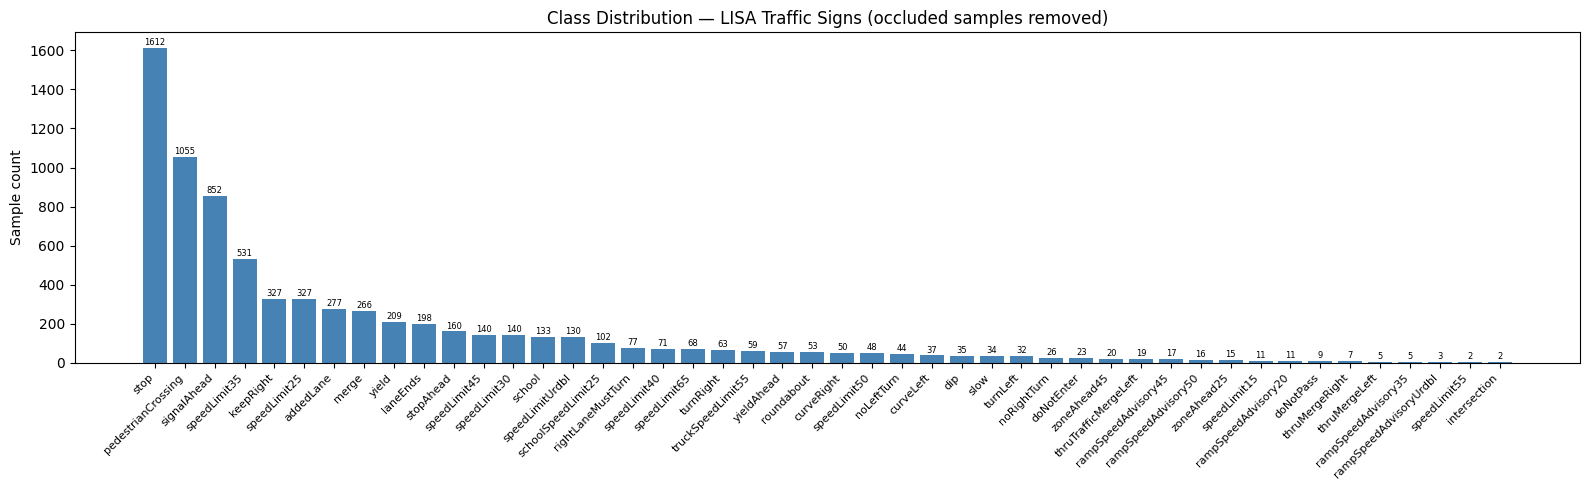

Saved: plot_class_distribution.png


In [19]:
ann = pd.read_csv(os.path.join(DATA_ROOT, 'allAnnotations.csv'), sep=';')
print(f'Raw annotations : {ann.shape}')

# Parse the combined occlusion string
occ_split               = ann['Occluded,On another road'].str.split(',', expand=True).astype(int)
ann['occluded_flag']    = occ_split[0]
ann['other_road_flag']  = occ_split[1]

ann_clean = ann[
    (ann['occluded_flag'] == 0) & (ann['other_road_flag'] == 0)
].reset_index(drop=True)

print(f'After filtering  : {len(ann_clean)} rows  ({len(ann)-len(ann_clean)} removed)')
print(f'Unique classes   : {ann_clean["Annotation tag"].nunique()}')

# ── Class distribution bar chart ──────────────────────────────────────────────
class_counts = ann_clean['Annotation tag'].value_counts()

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(class_counts.index, class_counts.values, color='steelblue')
ax.set_xticks(range(len(class_counts)))
ax.set_xticklabels(class_counts.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample count')
ax.set_title('Class Distribution — LISA Traffic Signs (occluded samples removed)')
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'plot_class_distribution.png'), dpi=150)
plt.show()
print('Saved: plot_class_distribution.png')

---
## Section 5 — Preprocessing Pipeline

**RAM strategy:** We stream through annotations one row at a time,  
writing directly into pre-allocated numpy arrays.  
No intermediate Python lists of image arrays are kept in memory,  
so peak RAM stays well below 1 GB.

Augmentation is applied inline in the same pass:
each annotation produces 4 rows in X (original + flip + rotate−15 + rotate+15).

### 5A — Resize  |  5B — Grayscale  |  5C — Normalize  |  5D — Augment
*(all applied in a single streaming pass)*

In [20]:
# ── Helper functions ──────────────────────────────────────────────────────────

def resize_image(img_bgr, size=TARGET_SIZE):
    """
    Resize BGR image to `size` (W, H).
    INTER_AREA is optimal for downscaling — avoids aliasing.
    Library: cv2
    """
    return cv2.resize(img_bgr, size, interpolation=cv2.INTER_AREA)


def to_grayscale_cv2(img_bgr):
    """
    BGR -> single-channel grayscale.
    cv2 formula: Y = 0.114*B + 0.587*G + 0.299*R  (luminosity weighting)
    Library: cv2
    """
    return cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)


def to_grayscale_pil(img_bgr):
    """
    Alternative grayscale via PIL — identical result for uint8 images.
    Library: PIL
    """
    return np.array(Image.fromarray(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)).convert('L'))


def normalize_flatten(img_gray):
    """
    Scale [0,255] -> [0.0,1.0] and flatten to 1-D feature vector.
    Input : (H, W) uint8  |  Output: (H*W,) float32
    float32 halves RAM vs float64 with no accuracy impact for these methods.
    Library: numpy
    """
    return (img_gray.astype(np.float32) / 255.0).flatten()


def flip_horizontal(img_gray):
    """Flip grayscale image left-to-right.  Library: cv2"""
    return cv2.flip(img_gray, 1)


def rotate_image(img_gray, angle_deg):
    """
    Rotate grayscale image around its centre by `angle_deg`.
    Empty border pixels filled with image mean (avoids black corners).
    Library: cv2
    """
    h, w = img_gray.shape
    M = cv2.getRotationMatrix2D((w // 2, h // 2), angle_deg, 1.0)
    return cv2.warpAffine(
        img_gray, M, (w, h),
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=int(img_gray.mean())
    )


print('Helper functions defined.')

Helper functions defined.


In [21]:
# ── Pre-allocate arrays (streaming pass — no intermediate image lists) ─────────
N_AUG      = 1 + len(AUG_ANGLES) + 1   # original + rotations + flip = 4
N_TOTAL    = len(ann_clean) * N_AUG
N_FEATURES = TARGET_SIZE[0] * TARGET_SIZE[1]  # 64*64 = 4096

print(f'Samples before augmentation : {len(ann_clean):,}')
print(f'Augmentation multiplier     : {N_AUG}x  (original + flip + {len(AUG_ANGLES)} rotations)')
print(f'Total samples               : {N_TOTAL:,}')
print(f'Feature dimension           : {N_FEATURES}')
print(f'Estimated RAM (float32)     : {N_TOTAL * N_FEATURES * 4 / 1e6:.0f} MB')

X         = np.zeros((N_TOTAL, N_FEATURES), dtype=np.float32)
y_labels  = []       # string labels, encoded after the loop
meta_rows = []       # crop metadata: original bounding box info per sample
skipped   = 0
idx       = 0        # running row pointer into X

for _, row in ann_clean.iterrows():
    img_path = os.path.join(DATA_ROOT, row['Filename'])
    if not os.path.exists(img_path):
        skipped += 1
        continue

    frame = cv2.imread(img_path, cv2.IMREAD_COLOR)
    if frame is None:
        skipped += 1
        continue

    x1 = int(row['Upper left corner X'])
    y1 = int(row['Upper left corner Y'])
    x2 = int(row['Lower right corner X'])
    y2 = int(row['Lower right corner Y'])

    crop = frame[y1:y2, x1:x2]
    if crop.size == 0:
        skipped += 1
        continue

    label = row['Annotation tag']

    # ── Steps 5A + 5B: resize then grayscale ──────────────────────────────────
    gray = to_grayscale_cv2(resize_image(crop))

    # ── Steps 5C + 5D: normalize + augment, write directly into X ─────────────
    variants = [
        ('original', gray),
        ('flip',     flip_horizontal(gray)),
    ]
    for angle in AUG_ANGLES:
        variants.append((f'rot{angle:+d}', rotate_image(gray, angle)))

    for aug_tag, img in variants:
        X[idx] = normalize_flatten(img)
        y_labels.append(label)
        meta_rows.append({
            'sample_idx':  idx,
            'aug_type':    aug_tag,
            'label':       label,
            'source_file': row['Filename'],
            'bbox_x1': x1, 'bbox_y1': y1,
            'bbox_x2': x2, 'bbox_y2': y2,
            'crop_w':  x2 - x1,
            'crop_h':  y2 - y1,
        })
        idx += 1

# Trim pre-allocated array in case some rows were skipped
X = X[:idx]
y_labels = y_labels[:idx]

le = LabelEncoder()
y  = le.fit_transform(y_labels)

meta_df = pd.DataFrame(meta_rows[:idx])

print(f'\nDone.  X shape : {X.shape}')
print(f'Skipped        : {skipped}')
print(f'Classes        : {len(le.classes_)}  -> {le.classes_}')
print(f'Pixel range    : [{X.min():.3f}, {X.max():.3f}]')

Samples before augmentation : 7,378
Augmentation multiplier     : 4x  (original + flip + 2 rotations)
Total samples               : 29,512
Feature dimension           : 4096
Estimated RAM (float32)     : 484 MB

Done.  X shape : (29512, 4096)
Skipped        : 0
Classes        : 46  -> ['addedLane' 'curveLeft' 'curveRight' 'dip' 'doNotEnter' 'doNotPass'
 'intersection' 'keepRight' 'laneEnds' 'merge' 'noLeftTurn' 'noRightTurn'
 'pedestrianCrossing' 'rampSpeedAdvisory20' 'rampSpeedAdvisory35'
 'rampSpeedAdvisory45' 'rampSpeedAdvisory50' 'rampSpeedAdvisoryUrdbl'
 'rightLaneMustTurn' 'roundabout' 'school' 'schoolSpeedLimit25'
 'signalAhead' 'slow' 'speedLimit15' 'speedLimit25' 'speedLimit30'
 'speedLimit35' 'speedLimit40' 'speedLimit45' 'speedLimit50'
 'speedLimit55' 'speedLimit65' 'speedLimitUrdbl' 'stop' 'stopAhead'
 'thruMergeLeft' 'thruMergeRight' 'thruTrafficMergeLeft'
 'truckSpeedLimit55' 'turnLeft' 'turnRight' 'yield' 'yieldAhead'
 'zoneAhead25' 'zoneAhead45']
Pixel range    : [0.000

---
## Section 6 — Save to Google Drive

Files saved:

| File | Contents |
|------|----------|
| `X.npy` | Feature matrix — shape `(N, 4096)`, float32 |
| `y.npy` | Integer class labels — shape `(N,)` |
| `le_classes.npy` | Class name strings (LabelEncoder mapping) |
| `crop_metadata.csv` | Per-sample record: label, aug type, original bounding box |

The `crop_metadata.csv` is the permanent record of the annotation bounding boxes.  
Once this is saved you do not need to keep the raw frames or the annotations CSV  
in memory — the preprocessing step is complete.

In [22]:
# ── Save feature matrix and labels ────────────────────────────────────────────
np.save(os.path.join(DRIVE_SAVE_PATH, 'X.npy'), X)
np.save(os.path.join(DRIVE_SAVE_PATH, 'y.npy'), y)
np.save(os.path.join(DRIVE_SAVE_PATH, 'le_classes.npy'), le.classes_)

# ── Save crop metadata (bounding box record) ──────────────────────────────────
meta_df.to_csv(os.path.join(DRIVE_SAVE_PATH, 'crop_metadata.csv'), index=False)

print('Saved to Google Drive:')
for f in ['X.npy', 'y.npy', 'le_classes.npy', 'crop_metadata.csv']:
    fpath = os.path.join(DRIVE_SAVE_PATH, f)
    size_mb = os.path.getsize(fpath) / 1e6
    print(f'  {f:<22} {size_mb:.1f} MB')

# ── Free preprocessing RAM now that everything is saved ───────────────────────
del X, y, y_labels, meta_rows, meta_df, ann, ann_clean
gc.collect()
print('\nIntermediate data cleared from RAM.')

Saved to Google Drive:
  X.npy                  483.5 MB
  y.npy                  0.2 MB
  le_classes.npy         0.0 MB
  crop_metadata.csv      4.4 MB

Intermediate data cleared from RAM.


---
## Section 7 — Verification Plots
*(Saved as PNGs to Drive so all members get identical plots)*

Reload from Drive, make verification plots, save them.  
Members can open the PNG files directly from the shared folder.

In [23]:
# ── Reload from Drive ─────────────────────────────────────────────────────────
X_verify    = np.load(os.path.join(DRIVE_SAVE_PATH, 'X.npy'))
y_verify    = np.load(os.path.join(DRIVE_SAVE_PATH, 'y.npy'))
classes     = np.load(os.path.join(DRIVE_SAVE_PATH, 'le_classes.npy'), allow_pickle=True)
meta_verify = pd.read_csv(os.path.join(DRIVE_SAVE_PATH, 'crop_metadata.csv'))

print(f'X shape    : {X_verify.shape}')
print(f'y shape    : {y_verify.shape}')
print(f'Classes    : {classes}')
print(f'Meta shape : {meta_verify.shape}')

X shape    : (29512, 4096)
y shape    : (29512,)
Classes    : ['addedLane' 'curveLeft' 'curveRight' 'dip' 'doNotEnter' 'doNotPass'
 'intersection' 'keepRight' 'laneEnds' 'merge' 'noLeftTurn' 'noRightTurn'
 'pedestrianCrossing' 'rampSpeedAdvisory20' 'rampSpeedAdvisory35'
 'rampSpeedAdvisory45' 'rampSpeedAdvisory50' 'rampSpeedAdvisoryUrdbl'
 'rightLaneMustTurn' 'roundabout' 'school' 'schoolSpeedLimit25'
 'signalAhead' 'slow' 'speedLimit15' 'speedLimit25' 'speedLimit30'
 'speedLimit35' 'speedLimit40' 'speedLimit45' 'speedLimit50'
 'speedLimit55' 'speedLimit65' 'speedLimitUrdbl' 'stop' 'stopAhead'
 'thruMergeLeft' 'thruMergeRight' 'thruTrafficMergeLeft'
 'truckSpeedLimit55' 'turnLeft' 'turnRight' 'yield' 'yieldAhead'
 'zoneAhead25' 'zoneAhead45']
Meta shape : (29512, 10)


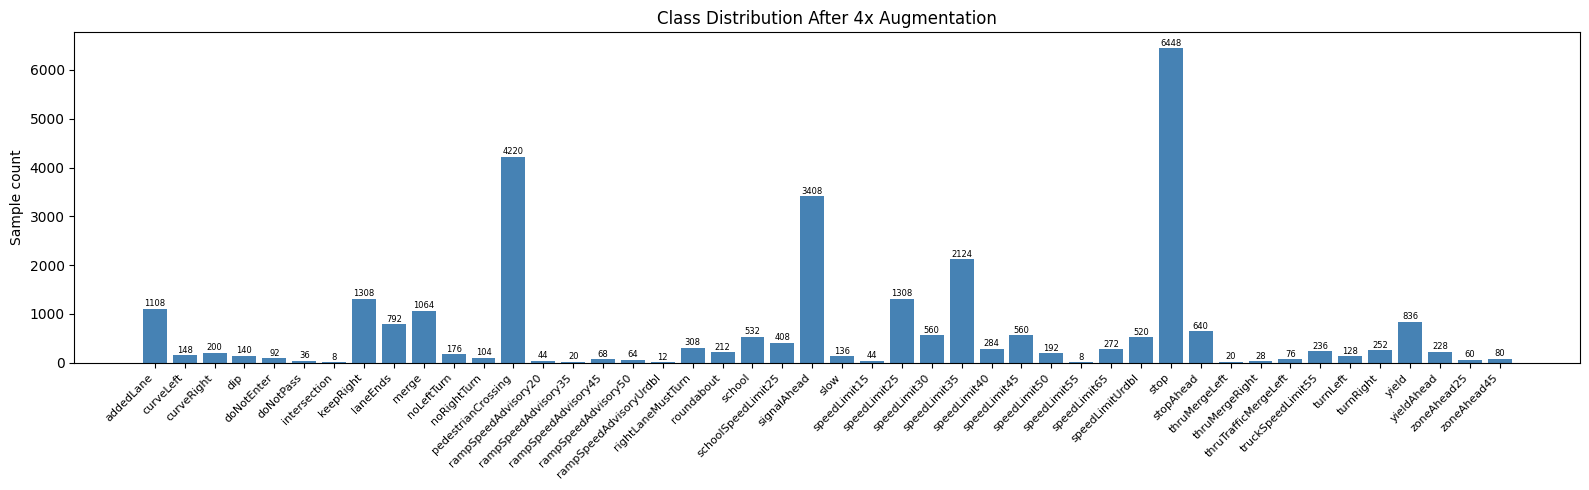

Saved: plot_class_dist_augmented.png


In [24]:
# ── Plot 1: Class distribution after augmentation ─────────────────────────────
unique, counts = np.unique(y_verify, return_counts=True)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(classes[unique], counts, color='steelblue')
ax.set_xticks(range(len(unique)))
ax.set_xticklabels(classes[unique], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Sample count')
ax.set_title('Class Distribution After 4x Augmentation')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(count), ha='center', va='bottom', fontsize=6)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'plot_class_dist_augmented.png'), dpi=150)
plt.show()
print('Saved: plot_class_dist_augmented.png')

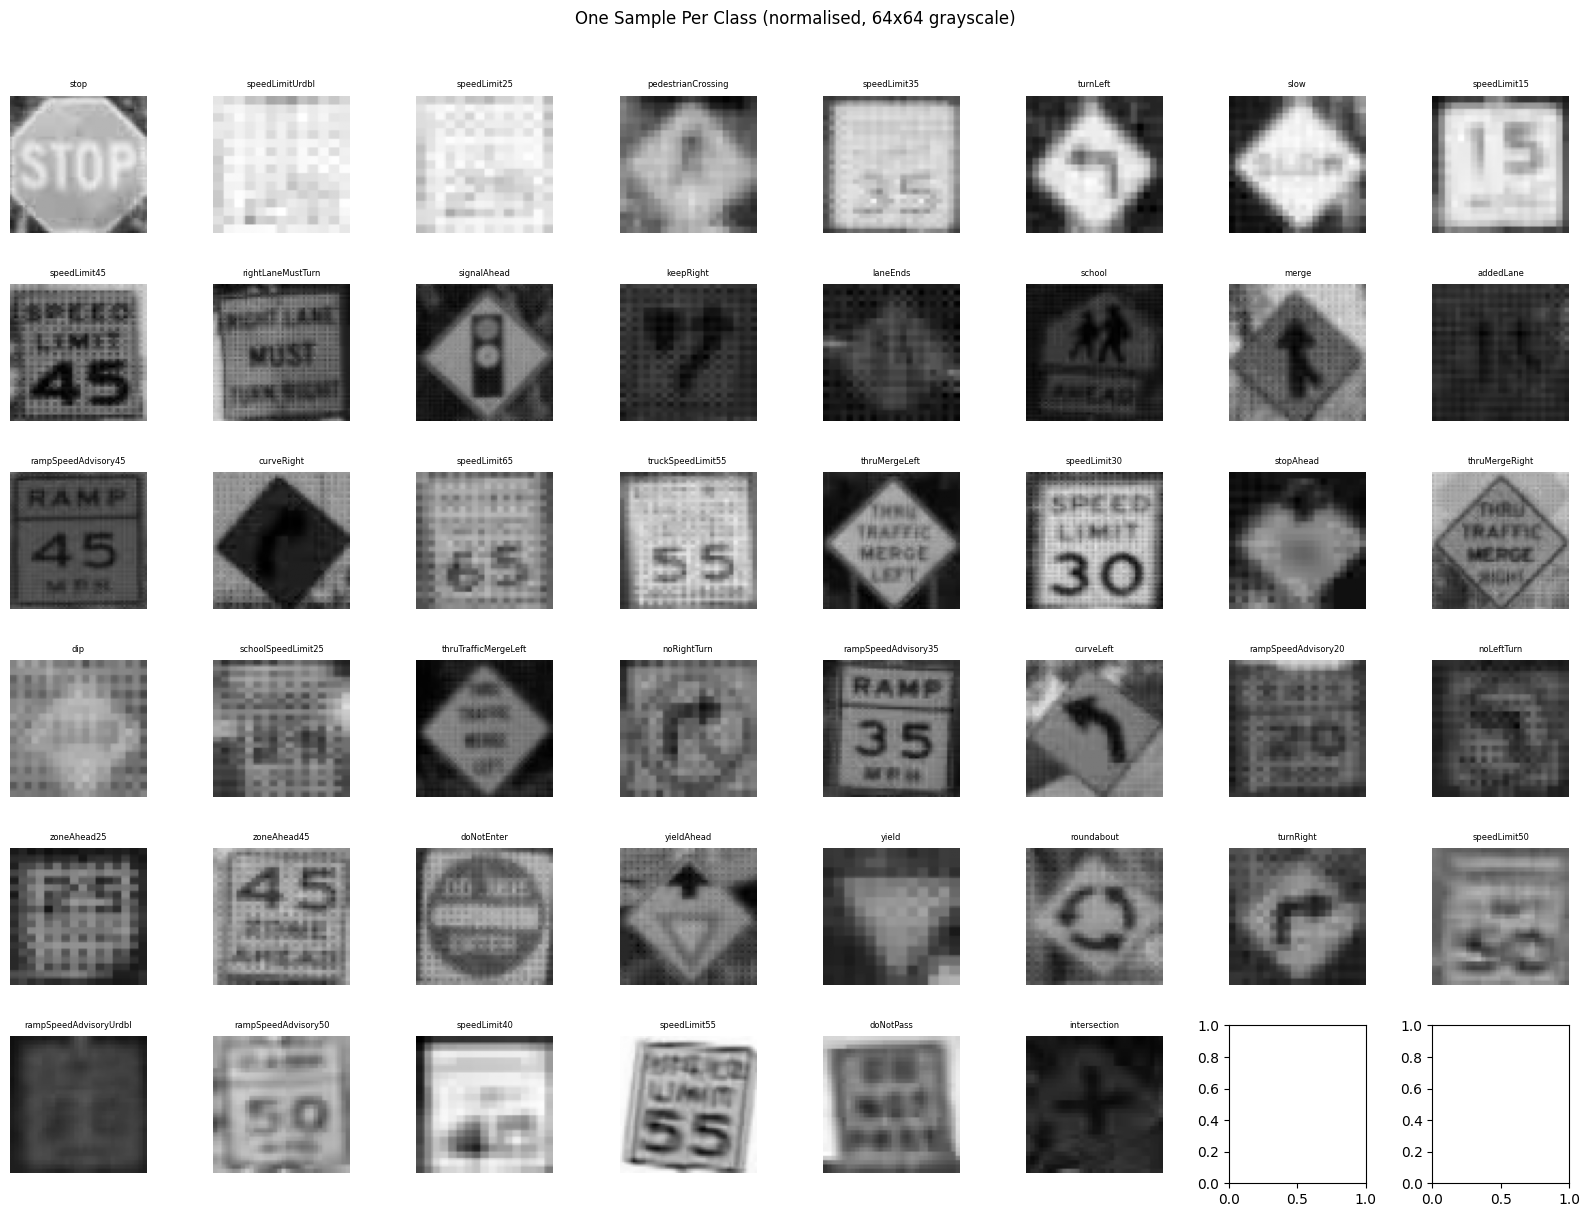

Saved: plot_sample_grid.png


In [25]:
# ── Plot 2: Sample grid — one original crop per class ─────────────────────────
# Pull index of the first 'original' sample for each class
orig_meta = meta_verify[meta_verify['aug_type'] == 'original'].drop_duplicates('label')
n_classes = len(orig_meta)
cols = 8
rows = int(np.ceil(n_classes / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
axes = axes.flat

for ax, (_, meta_row) in zip(axes, orig_meta.iterrows()):
    feat_vec = X_verify[meta_row['sample_idx']]
    img_2d   = feat_vec.reshape(TARGET_SIZE[1], TARGET_SIZE[0])  # (H, W)
    ax.imshow(img_2d, cmap='gray', vmin=0, vmax=1)
    ax.set_title(meta_row['label'], fontsize=6)
    ax.axis('off')

# Hide unused axes
for ax in list(axes)[n_classes:]:
    ax.axis('off')

plt.suptitle('One Sample Per Class (normalised, 64x64 grayscale)', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'plot_sample_grid.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: plot_sample_grid.png')

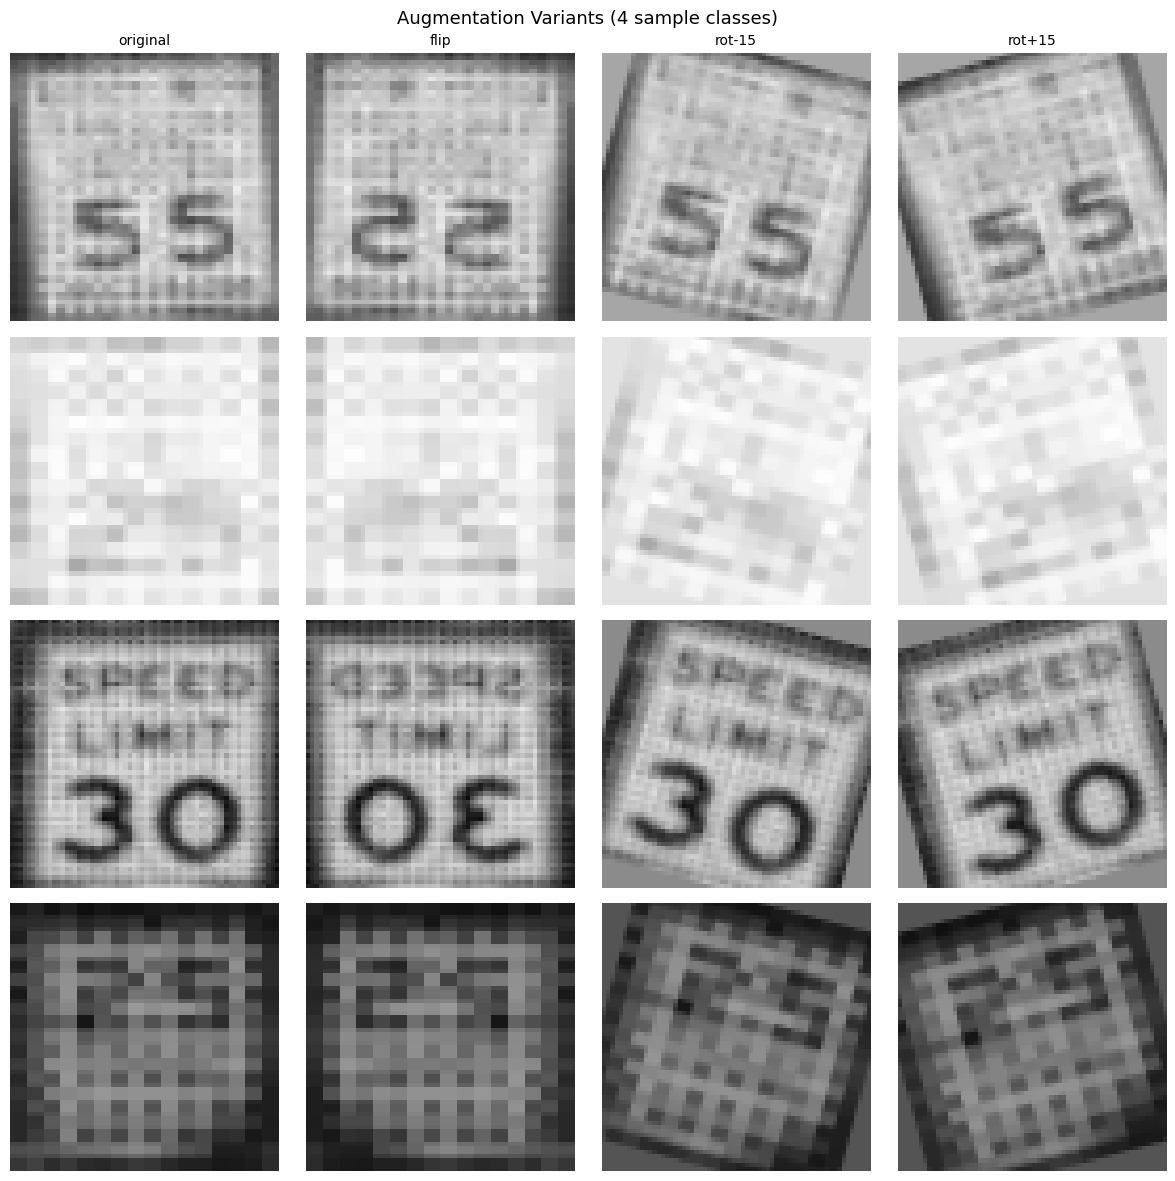

Saved: plot_augmentation_examples.png


In [26]:
# ── Plot 3: Augmentation comparison for 4 random classes ──────────────────────
np.random.seed(RANDOM_STATE)
sample_classes = np.random.choice(classes, size=4, replace=False)
aug_types = ['original', 'flip', 'rot-15', 'rot+15']

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for row_i, cls in enumerate(sample_classes):
    for col_i, aug in enumerate(aug_types):
        subset = meta_verify[(meta_verify['label'] == cls) & (meta_verify['aug_type'] == aug)]
        ax = axes[row_i, col_i]
        if len(subset) == 0:
            ax.axis('off')
            continue
        feat_vec = X_verify[subset.iloc[0]['sample_idx']]
        ax.imshow(feat_vec.reshape(TARGET_SIZE[1], TARGET_SIZE[0]), cmap='gray', vmin=0, vmax=1)
        if row_i == 0:
            ax.set_title(aug, fontsize=10)
        if col_i == 0:
            ax.set_ylabel(cls, fontsize=9)
        ax.axis('off')

plt.suptitle('Augmentation Variants (4 sample classes)', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'plot_augmentation_examples.png'), dpi=150)
plt.show()
print('Saved: plot_augmentation_examples.png')

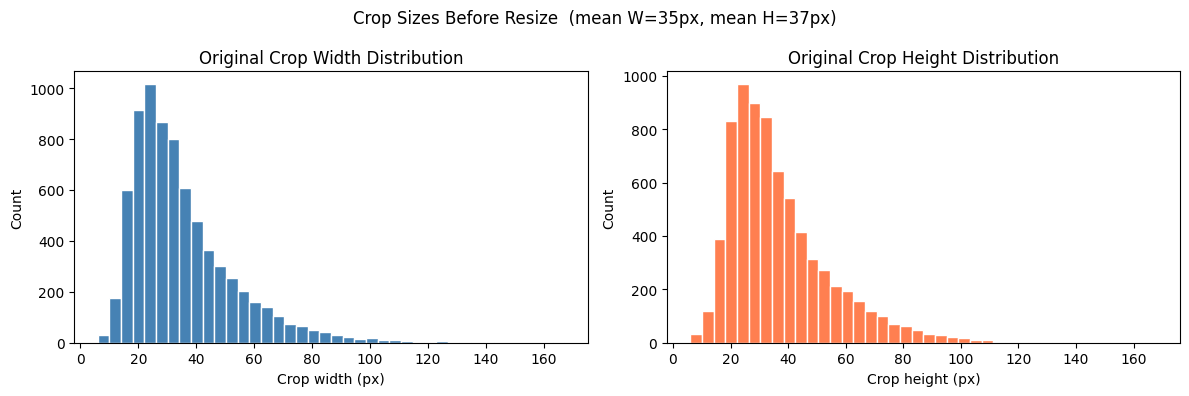

Saved: plot_crop_size_dist.png

=== Preprocessing complete ===
All files in /content/drive/Shareddrives/MATH 250: Traffic Sign Classification:
  Classifiers_an.ipynb
  Classifiers_anna.ipynb
  Classifiers_megan.ipynb
  Classifiers_robert.ipynb
  Classifiers_siling.ipynb
  Math 250 Project Proposal Presentation.gslides
  Math 250 Project Proposal.gdoc
  X.npy
  crop_metadata.csv
  le_classes.npy
  math250_member_template.ipynb
  math250_preprocessing.ipynb
  math_250_traffic_sign_classification.ipynb
  math_250_traffic_sign_v2.ipynb
  plot_augmentation_examples.png
  plot_class_dist_augmented.png
  plot_class_distribution.png
  plot_crop_size_dist.png
  plot_sample_grid.png
  project notes.gdoc
  schedule.gdoc
  y.npy


In [27]:
# ── Plot 4: Crop size distribution (from metadata — original crops only) ───────
orig_only = meta_verify[meta_verify['aug_type'] == 'original']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist(orig_only['crop_w'], bins=40, color='steelblue', edgecolor='white')
ax1.set_xlabel('Crop width (px)')
ax1.set_ylabel('Count')
ax1.set_title('Original Crop Width Distribution')

ax2.hist(orig_only['crop_h'], bins=40, color='coral', edgecolor='white')
ax2.set_xlabel('Crop height (px)')
ax2.set_ylabel('Count')
ax2.set_title('Original Crop Height Distribution')

plt.suptitle(f'Crop Sizes Before Resize  (mean W={orig_only["crop_w"].mean():.0f}px, '
             f'mean H={orig_only["crop_h"].mean():.0f}px)')
plt.tight_layout()
plt.savefig(os.path.join(DRIVE_SAVE_PATH, 'plot_crop_size_dist.png'), dpi=150)
plt.show()
print('Saved: plot_crop_size_dist.png')
print()
print('=== Preprocessing complete ===')
print(f'All files in {DRIVE_SAVE_PATH}:')
for f in sorted(os.listdir(DRIVE_SAVE_PATH)):
    print(f'  {f}')